# **Comparative Analysis on DAWN**

This notebook compares the preliminary in-domain results obtained with YOLOv11 and Faster R-CNN on the DAWN dataset.


Objectives:
*   Compare overall detection performance
*   Compare weather-specific performance

*   Visualize the speed-accuracy trade-off
*  Prepare tables and figures for the dissertation


### Connect to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Imports librairies

In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Define paths

In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Dissertation")

YOLO_RUN_DIR = BASE_DIR / "Runs/yolo/dawn_in_domain_yolo11s_seed42"

FRCNN_RUN_DIR = BASE_DIR / "Runs/faster_rcnn/dawn_indomain_fasterrcnn_r50fpn_seed42"

YOLO_WEATHER_JSON = YOLO_RUN_DIR / "weather_results_summary.json"

FRCNN_RESULTS_JSON = FRCNN_RUN_DIR / "dawn_faster_rcnn_in_domain_results_summary.json"

COMPARISON_DIR = BASE_DIR / "Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)


print("YOLO JSON exists:", YOLO_WEATHER_JSON.exists())
print("Faster R-CNN JSON exists:", FRCNN_RESULTS_JSON.exists())
print("Comparison output:", COMPARISON_DIR)

YOLO JSON exists: True
Faster R-CNN JSON exists: True
Comparison output: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42


In [ ]:
csv_path = COMPARISON_DIR / "dawn_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv"

json_path = COMPARISON_DIR / "dawn_indomain_yolo_vs_fasterrcnn_seed42_comparison.json"

# **Load Results**

In [ ]:
#YOLO results

with open(YOLO_WEATHER_JSON, "r") as f:
    yolo_results = json.load(f)

yolo_results


{'global': {'map50': 0.5812452930219402,
  'map50_95': 0.3396287319883049,
  'mp': 0.5776077486323775,
  'mr': 0.5927543844416351},
 'fog': {'map50': 0.6152619734360698,
  'map50_95': 0.3846645751141019,
  'mp': 0.8054512859364454,
  'mr': 0.5621335015027892},
 'rain': {'map50': 0.5429430571864977,
  'map50_95': 0.3572607295115205,
  'mp': 0.6182433491817393,
  'mr': 0.5737429511278196},
 'snow': {'map50': 0.6822179184938334,
  'map50_95': 0.4520038033502384,
  'mp': 0.7550325595926238,
  'mr': 0.6028949924924568}}

In [ ]:
yolo_fps_json = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/yolo/dawn_in_domain_yolo11s_seed42/yolo_fps_results.json"
)

with open(yolo_fps_json, "r") as f:
    yolo_fps = json.load(f)

yolo_fps

{'fog': {'total_time': 0.5057775974273682,
  'avg_inference_time': 0.012644439935684204,
  'FPS': 79.08614419353394},
 'rain': {'total_time': 0.49079322814941406,
  'avg_inference_time': 0.012269830703735352,
  'FPS': 81.5007170144219},
 'snow': {'total_time': 0.49833250045776367,
  'avg_inference_time': 0.012458312511444091,
  'FPS': 80.2676926816059}}

In [ ]:
#Faster R-CNN results

with open(FRCNN_RESULTS_JSON, "r") as f:
    frcnn_results = json.load(f)

frcnn_results = pd.DataFrame(frcnn_results)

# **Comparison table**

In [ ]:
rows = []

# YOLO results
for split_name, values in yolo_results.items():

    if split_name == "fog":
        fps_value = yolo_fps["fog"]["FPS"]

    elif split_name == "rain":
        fps_value = yolo_fps["rain"]["FPS"]

    elif split_name == "snow":
        fps_value = yolo_fps["snow"]["FPS"]

    else:
        fps_value = np.nan

    rows.append({
        "split": split_name,
        "model": "YOLOv11s",

        "mAP50-95": values.get("map50_95", np.nan),
        "mAP50": values.get("map50", np.nan),
        "mAP75": np.nan,

        "Precision": values.get("mp", np.nan),
        "Recall": values.get("mr", np.nan),

        "mAR100": np.nan,

        "FPS": fps_value
    })


# Faster R-CNN results
for _, row in frcnn_results.iterrows():

    rows.append({
        "split": row["condition"],
        "model": "Faster R-CNN",

        "mAP50-95": row["mAP50-95"],
        "mAP50": row["mAP50"],
        "mAP75": row["mAP75"],

        "Precision": np.nan,
        "Recall": np.nan,

        "mAR100": row.get("mAR100", np.nan),

        "FPS": row["FPS"]
    })


comparison_df = pd.DataFrame(rows)

split_order = ["global", "fog", "rain", "snow"]
model_order = ["YOLOv11s", "Faster R-CNN"]

comparison_df["split"] = pd.Categorical(
    comparison_df["split"],
    categories=split_order,
    ordered=True
)

comparison_df["model"] = pd.Categorical(
    comparison_df["model"],
    categories=model_order,
    ordered=True
)

comparison_df = comparison_df.sort_values(
    ["split", "model"]
).reset_index(drop=True)

comparison_df

,split,model,mAP50-95,mAP50,mAP75,Precision,Recall,mAR100,FPS
0,global,YOLOv11s,0.339629,0.581245,NaN,0.577608,0.592754,NaN,NaN
1,global,Faster R-CNN,0.432050,0.655329,0.506732,NaN,NaN,NaN,20.323207
2,fog,YOLOv11s,0.384665,0.615262,NaN,0.805451,0.562134,NaN,79.086144
3,fog,Faster R-CNN,0.384682,0.599742,0.475654,NaN,NaN,NaN,20.329152
4,rain,YOLOv11s,0.357261,0.542943,NaN,0.618243,0.573743,NaN,81.500717
5,rain,Faster R-CNN,0.411721,0.613088,0.466044,NaN,NaN,NaN,20.227659
6,snow,YOLOv11s,0.452004,0.682218,NaN,0.755033,0.602895,NaN,80.267693
7,snow,Faster R-CNN,0.499745,0.753156,0.578497,NaN,NaN,NaN,20.412810


In [ ]:
#
yolo_global_fps = np.mean([
    yolo_fps["fog"]["FPS"],
    yolo_fps["rain"]["FPS"],
    yolo_fps["snow"]["FPS"]
])

comparison_df.loc[
    (comparison_df["split"] == "global") &
    (comparison_df["model"] == "YOLOv11s"),
    "FPS"
] = yolo_global_fps

print("Updated comparison DataFrame:")
comparison_df

Updated comparison DataFrame:


,split,model,mAP50-95,mAP50,mAP75,Precision,Recall,mAR100,FPS
0,global,YOLOv11s,0.339629,0.581245,NaN,0.577608,0.592754,NaN,80.284851
1,global,Faster R-CNN,0.432050,0.655329,0.506732,NaN,NaN,NaN,20.323207
2,fog,YOLOv11s,0.384665,0.615262,NaN,0.805451,0.562134,NaN,79.086144
3,fog,Faster R-CNN,0.384682,0.599742,0.475654,NaN,NaN,NaN,20.329152
4,rain,YOLOv11s,0.357261,0.542943,NaN,0.618243,0.573743,NaN,81.500717
5,rain,Faster R-CNN,0.411721,0.613088,0.466044,NaN,NaN,NaN,20.227659
6,snow,YOLOv11s,0.452004,0.682218,NaN,0.755033,0.602895,NaN,80.267693
7,snow,Faster R-CNN,0.499745,0.753156,0.578497,NaN,NaN,NaN,20.412810


### Save Comparison table

In [ ]:
comparison_df.to_csv(csv_path, index=False)

comparison_df.to_json(
    json_path,
    orient="records",
    indent=4
)

print("Comparison files saved.")


Comparison files saved.


In [ ]:
print("CSV:", csv_path)
print("JSON:", json_path)

CSV: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42/dawn_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv
JSON: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42/dawn_indomain_yolo_vs_fasterrcnn_seed42_comparison.json


# **Visualization**

In [ ]:
def grouped_bar_plot(df, metric, title, ylabel, output_name):
    plot_df = df[["split", "model", metric]].dropna()

    pivot_df = plot_df.pivot(index="split", columns="model", values=metric)

    split_order = ["global", "fog", "rain", "snow"]
    pivot_df = pivot_df.loc[[s for s in split_order if s in pivot_df.index]]

    ax = pivot_df.plot(kind="bar", figsize=(9, 5))

    ax.set_title(title)
    ax.set_xlabel("Evaluation split")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(1.0, pivot_df.max().max() + 0.1))
    ax.legend(title="Model")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.xticks(rotation=0)
    plt.tight_layout()

    output_path = COMPARISON_DIR / output_name
    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Saved:", output_path)

### Plot mAP50-95

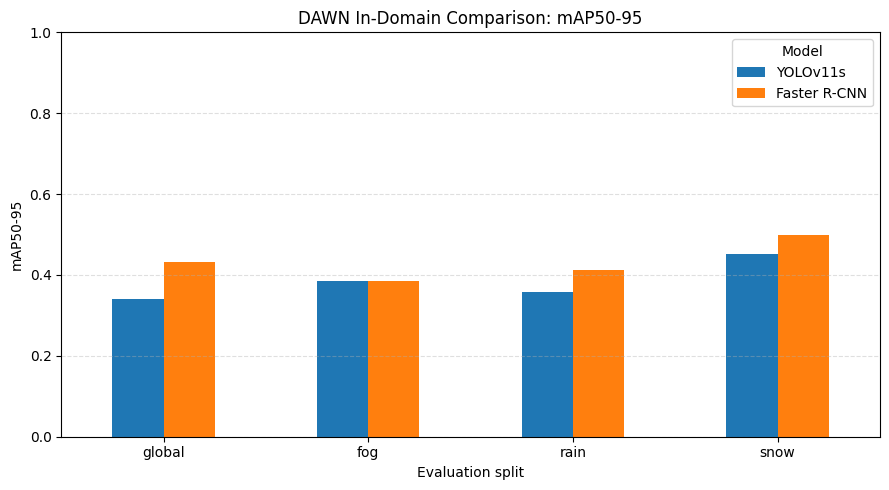

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42/map50_95_comparison.png


In [ ]:
grouped_bar_plot(
    comparison_df,
    metric="mAP50-95",
    title="DAWN In-Domain Comparison: mAP50-95",
    ylabel="mAP50-95",
    output_name="map50_95_comparison.png"
)

### Plot mAP50

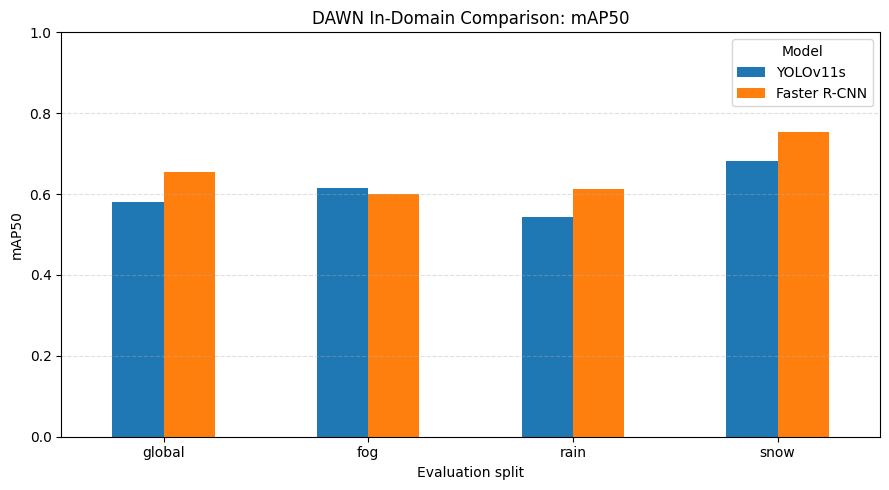

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42/map50_comparison.png


In [ ]:
grouped_bar_plot(
    comparison_df,
    metric="mAP50",
    title="DAWN In-Domain Comparison: mAP50",
    ylabel="mAP50",
    output_name="map50_comparison.png"
)

### Plot FPS

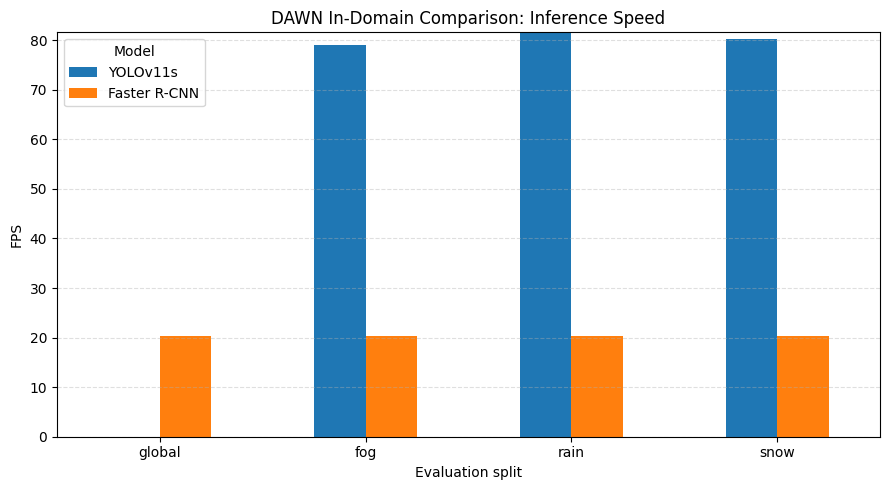

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42/fps_comparison.png


In [ ]:
grouped_bar_plot(
    comparison_df,
    metric="FPS",
    title="DAWN In-Domain Comparison: Inference Speed",
    ylabel="FPS",
    output_name="fps_comparison.png"
)

# **Observations**
### Interim


*   Faster R-CNN achieved higher global mAP@50 than YOLOv11 in the preliminary DAWN experiments.
*   YOLOv11 remained substantially faster and more suitable for real-time use.

*   Snow yielded the highest mAP@50 for both models in these preliminary results.
*   Rain appeared more challenging for Faster R-CNN than for YOLOv11.


Preliminary in-domain experiments on the DAWN dataset indicate that Faster R-CNN achieved higher detection accuracy than YOLOv11 in terms of mAP@50.
However, Faster R-CNN exhibited extremely low inference speed, confirming the expected trade-off between accuracy and computational efficiency.
Weather-specific evaluation further showed that both architectures performed best under snow conditions, while rain and fog remained more challenging depending on the detector.
These results should be interpreted as preliminary, since the Faster R-CNN baseline was trained on a reduced subset due CPU-only computational constraints.




### Finale

Final DAWN in-domain results suggest that Faster R-CNN achieves higher
detection accuracy across fog, rain, and snow conditions.

However, YOLOv11s maintains a substantial inference speed advantage,
reaching approximately 80 FPS compared to ~35 FPS for Faster R-CNN.

Snow conditions produced the highest detection performance for both
architectures, while rain appeared more challenging for YOLOv11s.